# Flood Image Detection with DeepLabV3+ Experiments 1-2

This notebook implements a **DeepLabV3+-based semantic segmentation pipeline** aligned with the project goal of identifying flooded regions from post-disaster aerial imagery.

This notebook utilizes the following parameters: with Dice + Cross Entropy loss function changes and larger input size (768 x 768)
- {"epochs": 40, "lr": 1e-4, "weight_decay": 1e-4},
- {"epochs": 40, "lr": 3e-4, "weight_decay": 1e-3}
with the implementation of a learning rate scheduler


It follows the project document by:
- using the **FloodNet-style split structure** (`train`, `val`, `test`)
- focusing on the flood-relevant classes:
  - `1 = Building Flooded`
  - `3 = Road Flooded`
  - `5 = Water`
- converting the original multi-class masks into a **binary flood vs. non-flood segmentation task**
- evaluating the model with **pixel accuracy, precision, recall, F1, and IoU**

The notebook is written so you can run it locally or in Colab/Jupyter after downloading the dataset folder.

## 1. Environment setup



In [1]:

# If you are in a fresh notebook environment, uncomment this:
# !pip install -q transformers accelerate evaluate datasets gdown albumentations opencv-python pillow matplotlib pandas scikit-learn tqdm

In [2]:

import os
import random
import math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation

In [3]:

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 2. Download or point to the dataset

Use the Google Drive folder you provided. If the folder is public, `gdown` can often download it directly. Otherwise, download it manually and set `DATASET_ROOT` to the local folder.

In [4]:
DATASET_ROOT = Path("../data/flood_dataset")

## 3. Expected folder structure

This notebook tries to automatically detect a common split layout such as:

```text
flood_dataset/
    train/
        image/ or images/
        mask/ or masks/
    val/
        image/ or images/
        mask/ or masks/
    test/
        image/ or images/
        mask/ or masks/
```

If your exact folder names differ, update the helper function below.

In [5]:
from pathlib import Path
import pandas as pd

def list_image_files(folder):
    exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}
    return sorted([p for p in folder.glob("*") if p.suffix.lower() in exts])

def match_image_mask_pairs(image_dir, mask_dir, split_name, group_name):
    rows = []

    image_files = list_image_files(image_dir)
    mask_files = list_image_files(mask_dir)

    # FloodNet masks appear to use image_stem + "_lab"
    mask_lookup = {m.stem: m for m in mask_files}

    matched = 0
    for img_path in image_files:
        img_stem = img_path.stem
        possible_keys = [img_stem, f"{img_stem}_lab"]

        mask_path = None
        for key in possible_keys:
            if key in mask_lookup:
                mask_path = mask_lookup[key]
                break

        if mask_path is not None:
            rows.append({
                "split": split_name,
                "group": group_name,
                "image_path": str(img_path),
                "mask_path": str(mask_path),
                "id": img_stem,
            })
            matched += 1

    print(f"{split_name}/{group_name}: matched {matched} image-mask pairs")
    return rows

def build_split_dataframe(dataset_root):
    dataset_root = Path(dataset_root)
    rows = []

    train_labeled = dataset_root / "Train" / "Labeled"

    flooded_img_dir = train_labeled / "Flooded" / "image"
    flooded_mask_dir = train_labeled / "Flooded" / "mask"
    nonflooded_img_dir = train_labeled / "Non-Flooded" / "image"
    nonflooded_mask_dir = train_labeled / "Non-Flooded" / "mask"

    if flooded_img_dir.exists() and flooded_mask_dir.exists():
        rows.extend(match_image_mask_pairs(flooded_img_dir, flooded_mask_dir, "train", "Flooded"))

    if nonflooded_img_dir.exists() and nonflooded_mask_dir.exists():
        rows.extend(match_image_mask_pairs(nonflooded_img_dir, nonflooded_mask_dir, "train", "Non-Flooded"))

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError("No image-mask pairs were found. Check DATASET_ROOT and folder names.")

    return df

df = build_split_dataframe(DATASET_ROOT)
df.head()

train/Flooded: matched 51 image-mask pairs
train/Non-Flooded: matched 347 image-mask pairs


,split,group,image_path,mask_path,id
0,train,Flooded,..\data\flood_dataset\Train\Labeled\Flooded\im...,..\data\flood_dataset\Train\Labeled\Flooded\ma...,10165
1,train,Flooded,..\data\flood_dataset\Train\Labeled\Flooded\im...,..\data\flood_dataset\Train\Labeled\Flooded\ma...,10166
2,train,Flooded,..\data\flood_dataset\Train\Labeled\Flooded\im...,..\data\flood_dataset\Train\Labeled\Flooded\ma...,6279
3,train,Flooded,..\data\flood_dataset\Train\Labeled\Flooded\im...,..\data\flood_dataset\Train\Labeled\Flooded\ma...,6614
4,train,Flooded,..\data\flood_dataset\Train\Labeled\Flooded\im...,..\data\flood_dataset\Train\Labeled\Flooded\ma...,6615


In [6]:
print(df["split"].value_counts())
print(df["group"].value_counts())
print(len(df))

split
train    398
Name: count, dtype: int64
group
Non-Flooded    347
Flooded         51
Name: count, dtype: int64
398


In [7]:

print("Dataset shape:", df.shape)
display(df["split"].value_counts())

Dataset shape: (398, 5)


split
train    398
Name: count, dtype: int64

## 4. Class definitions and binary flood mapping

The project document lists these original semantic classes:

- 0 Background
- 1 Building Flooded
- 2 Building Non-Flooded
- 3 Road Flooded
- 4 Road Non-Flooded
- 5 Water
- 6 Tree
- 7 Vehicle
- 8 Pool
- 9 Grass

To match the project goal, we map:
- **Flood = {1, 3, 5}**
- **Non-flood = everything else**

In [8]:

CLASS_NAMES = {
    0: "Background",
    1: "Building Flooded",
    2: "Building Non-Flooded",
    3: "Road Flooded",
    4: "Road Non-Flooded",
    5: "Water",
    6: "Tree",
    7: "Vehicle",
    8: "Pool",
    9: "Grass",
}

FLOOD_CLASSES = {1, 3, 5}
ID2LABEL = {0: "non_flood", 1: "flood"}
LABEL2ID = {"non_flood": 0, "flood": 1}
NUM_LABELS = 2

def load_mask(mask_path):
    return np.array(Image.open(mask_path))

def multiclass_to_binary(mask):
    return np.isin(mask, list(FLOOD_CLASSES)).astype(np.uint8)

## 6. Train/validation/test split tables

In [9]:
from sklearn.model_selection import train_test_split

# 1. Build dataframe from all labeled train pairs
df = build_split_dataframe(DATASET_ROOT)

# 2. Split that labeled dataframe into train and validation
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("train:", len(train_df))
print("val:", len(val_df))

train/Flooded: matched 51 image-mask pairs
train/Non-Flooded: matched 347 image-mask pairs
train: 318
val: 80


## 7. DeepLabV3+ preprocessing and dataset


In [10]:
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode

IMAGE_SIZE = (768, 768)

image_transform = T.Compose([
    T.Resize(IMAGE_SIZE),
    T.ToTensor(),
])

mask_resize = T.Resize(IMAGE_SIZE, interpolation=InterpolationMode.NEAREST)

class FloodDataset(Dataset):
    def __init__(self, dataframe, image_transform=image_transform, mask_resize=mask_resize):
        self.df = dataframe.reset_index(drop=True)
        self.image_transform = image_transform
        self.mask_resize = mask_resize

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        mask = load_mask(row["mask_path"])
        binary_mask = multiclass_to_binary(mask).astype(np.uint8)

        image = self.image_transform(image)

        binary_mask = Image.fromarray(binary_mask)
        binary_mask = self.mask_resize(binary_mask)
        binary_mask = torch.as_tensor(np.array(binary_mask), dtype=torch.long)

        return {
            "image": image,
            "mask": binary_mask
        }

train_dataset = FloodDataset(train_df)
val_dataset = FloodDataset(val_df)

In [11]:
BATCH_SIZE = 4
NUM_WORKERS = 2 if os.name != "nt" else 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

batch = next(iter(train_loader))
print(batch["image"].shape, batch["mask"].shape)

torch.Size([4, 3, 768, 768]) torch.Size([4, 768, 768])


## 8. Initialize Model for binary flood segmentation

The model is initialized with two labels:
- `0 = non_flood`
- `1 = flood`

Because the base checkpoint is pretrained for another task, `ignore_mismatched_sizes=True` lets the segmentation head be resized for the new label count. This is a standard adaptation pattern for transfer learning with SegFormer checkpoints. citeturn144765search1turn144765search3

In [20]:
import segmentation_models_pytorch as smp

def build_model():
    model = smp.DeepLabV3Plus(
        encoder_name="resnet101",      # Upgrading from ResNet50 for better features
        encoder_weights="imagenet", 
        in_channels=3, 
        classes=NUM_LABELS,                     # Binary flood vs non-flood
        activation=None                # Use None if your DiceCELoss handles logits
    )
    return model

print("Model factory ready.")

Model factory ready.


## 9. Metrics

In [21]:
def compute_batch_metrics(logits, labels):
    if logits.shape[-2:] != labels.shape[-2:]:
        logits = nn.functional.interpolate(
            logits,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

    preds = logits.argmax(dim=1)

    y_true = labels.detach().cpu().numpy().reshape(-1)
    y_pred = preds.detach().cpu().numpy().reshape(-1)

    metrics = {
        "pixel_accuracy": float((y_true == y_pred).mean()),
        "precision": float(precision_score(y_true, y_pred, average="binary", zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, average="binary", zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, average="binary", zero_division=0)),
        "iou": float(jaccard_score(y_true, y_pred, average="binary", zero_division=0)),
    }
    return metrics, preds


def aggregate_metrics(metric_list):
    if not metric_list:
        return {
            "pixel_accuracy": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
            "iou": 0.0,
        }
    keys = metric_list[0].keys()
    return {k: float(np.mean([m[k] for m in metric_list])) for k in keys}


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    metrics_all = []

    for batch in tqdm(loader, leave=False):
        images = batch["image"].to(device)
        labels = batch["mask"].to(device)

        with torch.set_grad_enabled(training):
            logits = model(images)

            if logits.shape[-2:] != labels.shape[-2:]:
                logits = nn.functional.interpolate(
                    logits,
                    size=labels.shape[-2:],
                    mode="bilinear",
                    align_corners=False
                )

            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        batch_metrics, _ = compute_batch_metrics(logits, labels)
        metrics_all.append(batch_metrics)

    avg_loss = total_loss / max(len(loader), 1)
    avg_metrics = aggregate_metrics(metrics_all)
    avg_metrics["loss"] = avg_loss
    return avg_metrics

In [22]:
PLOT_DIR = Path("../output/deeplab_experiment_plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_experiment_plots(history_df, exp_name, plot_dir=PLOT_DIR):
    # Loss plot
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
    plt.title(f"Loss - {exp_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"{exp_name}_loss.png", dpi=300, bbox_inches="tight")
    plt.close()

    # IoU plot
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_iou"], label="Train IoU")
    plt.plot(history_df["epoch"], history_df["val_iou"], label="Val IoU")
    plt.title(f"IoU - {exp_name}")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"{exp_name}_iou.png", dpi=300, bbox_inches="tight")
    plt.close()

    # F1 plot
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_f1"], label="Train F1")
    plt.plot(history_df["epoch"], history_df["val_f1"], label="Val F1")
    plt.title(f"F1 - {exp_name}")
    plt.xlabel("Epoch")
    plt.ylabel("F1")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"{exp_name}_f1.png", dpi=300, bbox_inches="tight")
    plt.close()

In [23]:
def predict_mask(model, image_path, image_transform, threshold=None):
    image = Image.open(image_path).convert("RGB")
    image_tensor = image_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(image_tensor)

        if logits.shape[-2:] != image.size[::-1]:
            logits = nn.functional.interpolate(
                logits,
                size=image.size[::-1],
                mode="bilinear",
                align_corners=False
            )

        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    return image, pred


def visualize_predictions_with_truth(model, dataframe, image_transform, n=4):
    subset = dataframe.sample(min(n, len(dataframe)), random_state=7)
    fig, axes = plt.subplots(len(subset), 3, figsize=(12, 4 * len(subset)))

    if len(subset) == 1:
        axes = np.expand_dims(axes, axis=0)

    for ax_row, (_, row) in zip(axes, subset.iterrows()):
        image = Image.open(row["image_path"]).convert("RGB")
        true_mask = multiclass_to_binary(load_mask(row["mask_path"]))
        _, pred_mask = predict_mask(model, row["image_path"], image_transform)

        ax_row[0].imshow(image)
        ax_row[0].set_title("Image")

        ax_row[1].imshow(true_mask, cmap="gray", vmin=0, vmax=1)
        ax_row[1].set_title("True binary mask")

        ax_row[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
        ax_row[2].set_title("Predicted binary mask")

        for ax in ax_row:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

In [24]:
def save_prediction_plot(model, dataframe, image_transform, exp_name, n=4, plot_dir=PLOT_DIR):
    subset = dataframe.sample(min(n, len(dataframe)), random_state=7)
    fig, axes = plt.subplots(len(subset), 3, figsize=(12, 4 * len(subset)))
    
    if len(subset) == 1:
        axes = np.expand_dims(axes, axis=0)

    for ax_row, (_, row) in zip(axes, subset.iterrows()):
        image = Image.open(row["image_path"]).convert("RGB")
        true_mask = multiclass_to_binary(load_mask(row["mask_path"]))
        _, pred_mask = predict_mask(model, row["image_path"], image_transform)

        ax_row[0].imshow(image)
        ax_row[0].set_title("Image")

        ax_row[1].imshow(true_mask, cmap="gray", vmin=0, vmax=1)
        ax_row[1].set_title("True mask")

        ax_row[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
        ax_row[2].set_title("Predicted mask")

        for ax in ax_row:
            ax.axis("off")

    safe_name = exp_name.replace(" ", "_").replace("/", "_")
    plt.tight_layout()
    plt.savefig(plot_dir / f"{safe_name}_predictions.png", dpi=300, bbox_inches="tight")
    plt.close()

## 10. Training loop

In [25]:
class DiceCELoss(nn.Module):
    def __init__(self, smooth=1e-6, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.smooth = smooth
        self.ce = nn.CrossEntropyLoss()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)

        probs = torch.softmax(logits, dim=1)[:, 1, :, :]
        targets_float = targets.float()

        probs = probs.contiguous().view(-1)
        targets_float = targets_float.contiguous().view(-1)

        intersection = (probs * targets_float).sum()
        dice = (2.0 * intersection + self.smooth) / (
            probs.sum() + targets_float.sum() + self.smooth
        )
        dice_loss = 1.0 - dice

        return self.ce_weight * ce_loss + self.dice_weight * dice_loss

In [26]:
# --------------------------------------------------
# Experiment grid
# --------------------------------------------------
EXPERIMENTS = [
    {"epochs": 40, "lr": 1e-4, "weight_decay": 1e-4},
    {"epochs": 40, "lr": 3e-4, "weight_decay": 1e-3}
]

SAVE_DIR = Path("deeplab_experiment_checkpoints")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

all_histories = []
experiment_summaries = []

best_overall_iou = -1.0
best_overall_config = None
best_overall_path = None
best_overall_history_df = None


Starting exp1_lr0.0001_wd0.0001_ep40


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 01
  Train: {'pixel_accuracy': 0.8302, 'precision': 0.4991, 'recall': 0.7871, 'f1': 0.546, 'iou': 0.4217, 'loss': 0.5383}
  Val:   {'pixel_accuracy': 0.9067, 'precision': 0.7305, 'recall': 0.625, 'f1': 0.6312, 'iou': 0.5077, 'loss': 0.4001}
  Saved best model to deeplab_experiment_checkpoints\exp1_lr0.0001_wd0.0001_ep40.pt


  0%|          | 0/80 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 39
  Train: {'pixel_accuracy': 0.9877, 'precision': 0.8842, 'recall': 0.9071, 'f1': 0.8924, 'iou': 0.8584, 'loss': 0.0975}
  Val:   {'pixel_accuracy': 0.9494, 'precision': 0.8237, 'recall': 0.7832, 'f1': 0.7846, 'iou': 0.6881, 'loss': 0.2107}


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 40
  Train: {'pixel_accuracy': 0.9881, 'precision': 0.9072, 'recall': 0.9304, 'f1': 0.917, 'iou': 0.8796, 'loss': 0.0802}
  Val:   {'pixel_accuracy': 0.9492, 'precision': 0.8132, 'recall': 0.8027, 'f1': 0.7916, 'iou': 0.6973, 'loss': 0.2098}


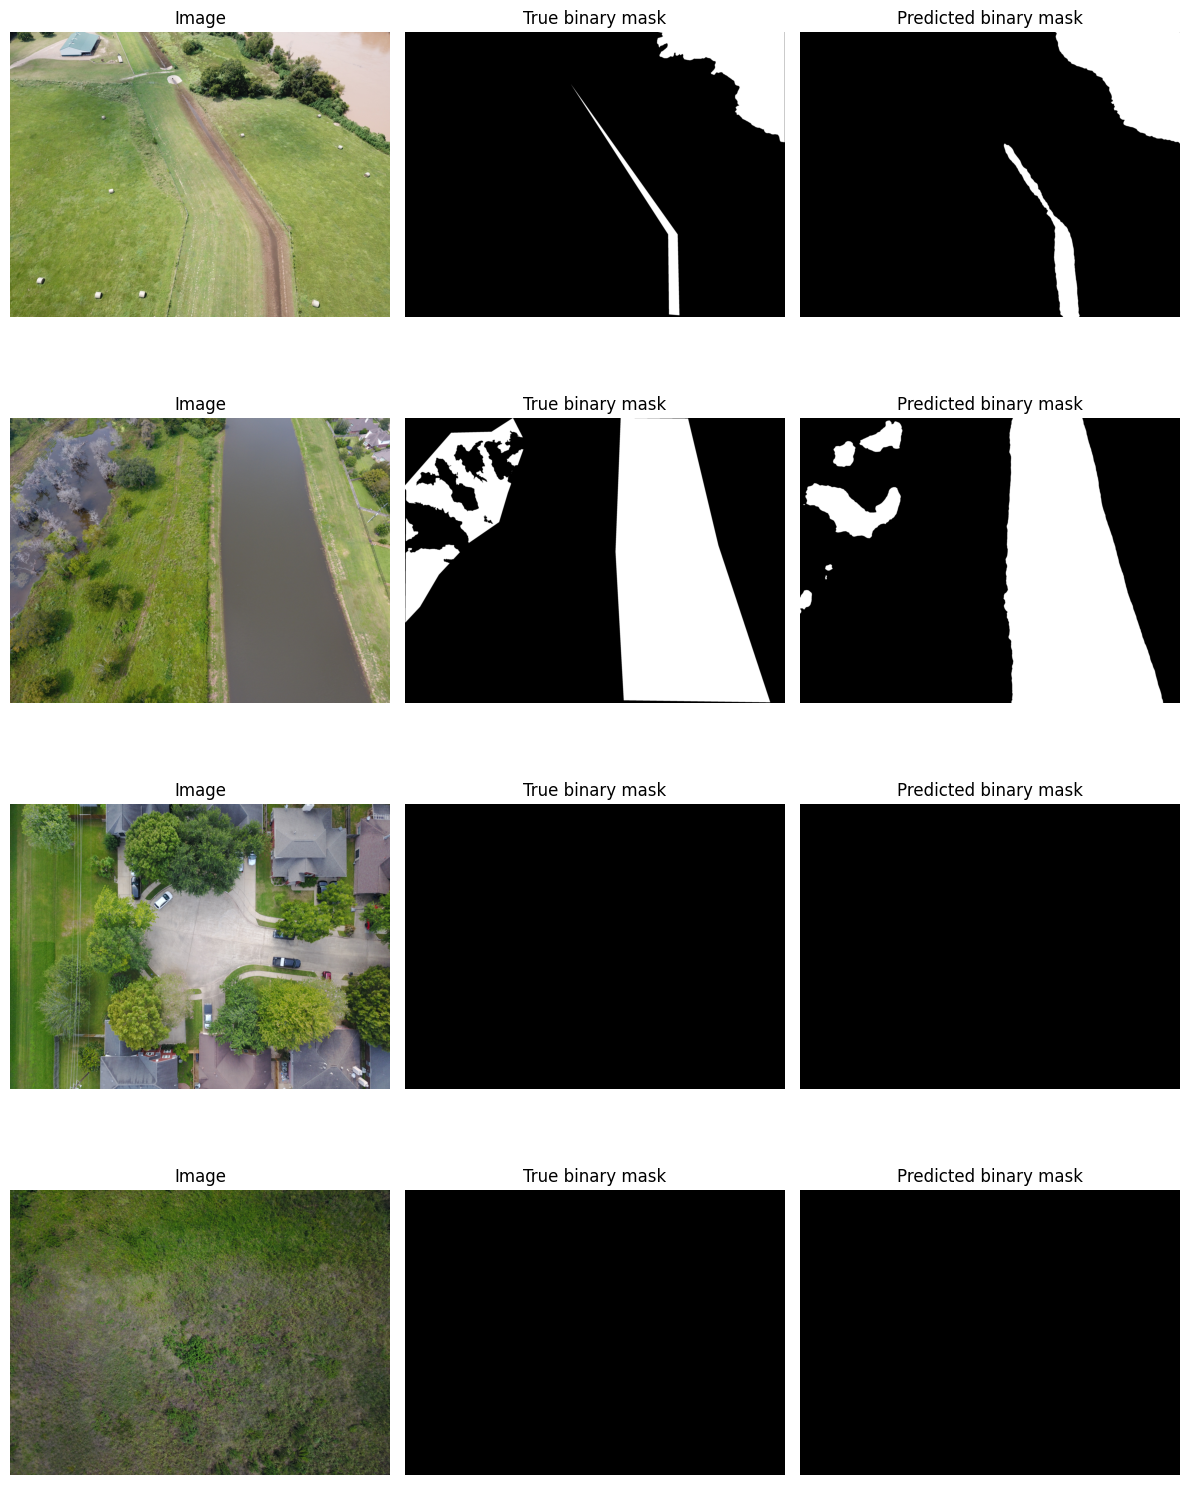


Starting exp2_lr0.0003_wd0.001_ep40


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 01
  Train: {'pixel_accuracy': 0.8394, 'precision': 0.5504, 'recall': 0.7147, 'f1': 0.5615, 'iou': 0.433, 'loss': 0.5013}
  Val:   {'pixel_accuracy': 0.9068, 'precision': 0.7842, 'recall': 0.559, 'f1': 0.6065, 'iou': 0.4998, 'loss': 0.3864}
  Saved best model to deeplab_experiment_checkpoints\exp2_lr0.0003_wd0.001_ep40.pt


  0%|          | 0/80 [00:00<?, ?it/s]

...

Epoch 33
  Train: {'pixel_accuracy': 0.9608, 'precision': 0.8067, 'recall': 0.8471, 'f1': 0.8156, 'iou': 0.74, 'loss': 0.1814}
  Val:   {'pixel_accuracy': 0.928, 'precision': 0.7888, 'recall': 0.7063, 'f1': 0.7114, 'iou': 0.5975, 'loss': 0.2769}


  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 34
  Train: {'pixel_accuracy': 0.9584, 'precision': 0.8033, 'recall': 0.8181, 'f1': 0.8001, 'iou': 0.7188, 'loss': 0.1934}
  Val:   {'pixel_accuracy': 0.9376, 'precision': 0.8079, 'recall': 0.7451, 'f1': 0.7468, 'iou': 0.6405, 'loss': 0.2479}


  0%|          | 0/80 [00:00<?, ?it/s]

In [ ]:
# --------------------------------------------------
# Run all experiments
# --------------------------------------------------
criterion = DiceCELoss(ce_weight=0.3, dice_weight=0.7)

for exp_num, exp in enumerate(EXPERIMENTS, start=1):
    epochs = exp["epochs"]
    lr = exp["lr"]
    wd = exp["weight_decay"]

    exp_name = f"exp{exp_num}_lr{lr}_wd{wd}_ep{epochs}"
    best_model_path = SAVE_DIR / f"{exp_name}.pt"

    print("\n" + "=" * 90)
    print(f"Starting {exp_name}")
    print("=" * 90)

    model = build_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    # scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.2, patience=4, cooldown=2)

    history = []
    best_val_iou = -1.0
    best_epoch = -1

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

        scheduler.step(val_metrics["iou"])

        row = {
            "experiment": exp_name,
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        history.append(row)

        print(f"Epoch {epoch:02d}")
        print("  Train:", {k: round(v, 4) for k, v in train_metrics.items()})
        print("  Val:  ", {k: round(v, 4) for k, v in val_metrics.items()})

        if val_metrics["iou"] > best_val_iou:
            best_val_iou = val_metrics["iou"]
            best_epoch = epoch
            torch.save(model.state_dict(), best_model_path)
            print(f"  Saved best model to {best_model_path}")

    history_df = pd.DataFrame(history)
    all_histories.append(history_df)

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.to(device)

    save_experiment_plots(history_df, exp_name)
    save_prediction_plot(model, val_df, image_transform, exp_name, n=4)
    visualize_predictions_with_truth(model, val_df, image_transform, n=4)

    experiment_summaries.append({
        "experiment": exp_name,
        "epochs": epochs,
        "learning_rate": lr,
        "weight_decay": wd,
        "best_val_iou": best_val_iou,
        "best_epoch": best_epoch,
        "model_path": str(best_model_path),
    })

    if best_val_iou > best_overall_iou:
        best_overall_iou = best_val_iou
        best_overall_config = exp_name
        best_overall_path = str(best_model_path)
        best_overall_history_df = history_df.copy()

summary_df = pd.DataFrame(experiment_summaries).sort_values(
    by="best_val_iou", ascending=False
).reset_index(drop=True)

display(summary_df)

print("\nBest overall experiment:", best_overall_config)
print("Best overall IoU:", round(best_overall_iou, 4))
print("Best overall model path:", best_overall_path)

In [ ]:
# Combined history across all experiments
full_history_df = pd.concat(all_histories, ignore_index=True)
display(full_history_df.head())

,experiment,epoch,train_pixel_accuracy,train_precision,train_recall,train_f1,train_iou,train_loss,val_pixel_accuracy,val_precision,val_recall,val_f1,val_iou,val_loss
0,exp12_lr0.0001_wd0.0001_ep60,1,0.845585,0.500336,0.679118,0.524068,0.396968,0.552091,0.914885,0.689830,0.788444,0.716707,0.591522,0.364380
1,exp12_lr0.0001_wd0.0001_ep60,2,0.891584,0.598102,0.738037,0.606104,0.482911,0.444640,0.917092,0.700288,0.818769,0.736822,0.619441,0.301856
2,exp12_lr0.0001_wd0.0001_ep60,3,0.915304,0.669353,0.784433,0.685735,0.572224,0.359289,0.922837,0.717365,0.793121,0.741218,0.627702,0.299817
3,exp12_lr0.0001_wd0.0001_ep60,4,0.925716,0.709533,0.780191,0.708737,0.595676,0.326441,0.916104,0.679570,0.879088,0.747237,0.633677,0.294242
4,exp12_lr0.0001_wd0.0001_ep60,5,0.925367,0.688929,0.786650,0.694232,0.584057,0.329831,0.912710,0.656548,0.856288,0.722709,0.600052,0.348999


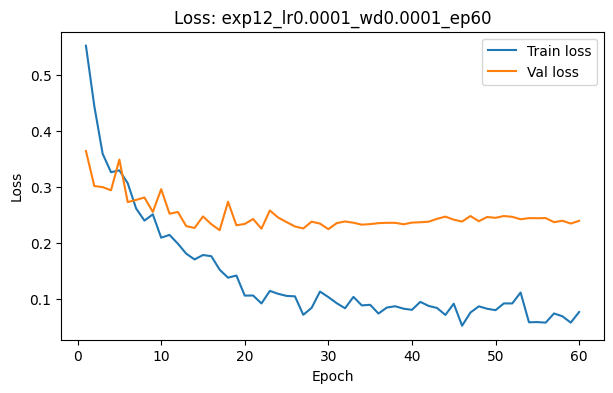

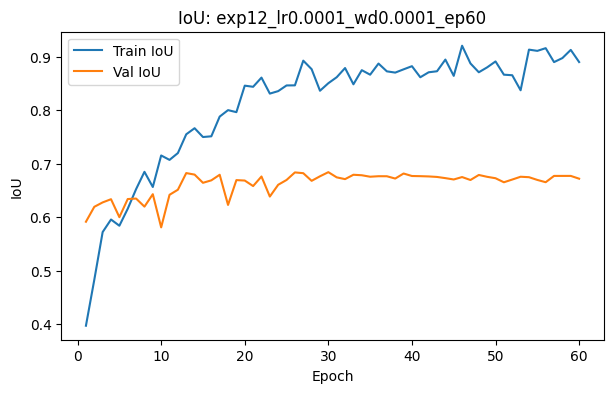

In [ ]:
# Plot loss for best overall experiment
plt.figure(figsize=(7, 4))
plt.plot(best_overall_history_df["epoch"], best_overall_history_df["train_loss"], label="Train loss")
plt.plot(best_overall_history_df["epoch"], best_overall_history_df["val_loss"], label="Val loss")
plt.title(f"Loss: {best_overall_config}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot IoU for best overall experiment
plt.figure(figsize=(7, 4))
plt.plot(best_overall_history_df["epoch"], best_overall_history_df["train_iou"], label="Train IoU")
plt.plot(best_overall_history_df["epoch"], best_overall_history_df["val_iou"], label="Val IoU")
plt.title(f"IoU: {best_overall_config}")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.show()

In [ ]:
# Load best overall model for visualization
best_model = build_model()
best_model.load_state_dict(torch.load(best_overall_path, map_location=device))
best_model.eval()

print(f"Loaded best overall model from: {best_overall_path}")

Loaded best overall model from: unet_experiment_checkpoints\exp12_lr0.0001_wd0.0001_ep60.pt


## 13. Optional: K-fold cross-validation note

Your project document mentions **5-fold cross-validation**. For segmentation on datasets that already provide `train/val/test` splits, a common approach is:

1. keep the original `test` set untouched for final reporting
2. perform 5-fold CV only within the training portion
3. select hyperparameters using the validation folds
4. retrain on full training data
5. evaluate once on the held-out test set

That is more computationally expensive, so this notebook implements the main train/val/test pipeline first.

## 14. Suggested report-ready interpretation prompts

After training, summarize results around:
- whether SegFormer improves flood localization on complex scenes
- whether recall is strong enough for disaster assessment settings
- whether class imbalance causes overprediction of non-flood regions
- whether IoU/F1 support the claim that the model accurately identifies flooded regions

You can then compare this notebook's results against your U-Net and DeepLabV3+ runs.